In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import title

df = pd.read_csv('air_pollution_dataset.csv')

df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Country             23036 non-null  str  
 1   City                23462 non-null  str  
 2   AQI Value           23463 non-null  int64
 3   AQI Category        23463 non-null  str  
 4   CO AQI Value        23463 non-null  int64
 5   CO AQI Category     23463 non-null  str  
 6   Ozone AQI Value     23463 non-null  int64
 7   Ozone AQI Category  23463 non-null  str  
 8   NO2 AQI Value       23463 non-null  int64
 9   NO2 AQI Category    23463 non-null  str  
 10  PM2.5 AQI Value     23463 non-null  int64
 11  PM2.5 AQI Category  23463 non-null  str  
dtypes: int64(5), str(7)
memory usage: 2.1 MB


In [3]:
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [4]:
df.columns

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='str')

In [14]:
df.groupby('Country')['PM2.5 AQI Value'].mean().sort_values(ascending=False).__round__(2)

Country
Republic of Korea    415.00
Bahrain              188.00
Mauritania           179.00
Pakistan             173.11
Aruba                163.00
                      ...  
Norway                18.57
Iceland               18.33
Maldives              15.00
Palau                  7.00
Solomon Islands        6.00
Name: PM2.5 AQI Value, Length: 175, dtype: float64

In [15]:
top_countries = df.groupby('Country')['PM2.5 AQI Value'].mean().sort_values(ascending=False).head(10).__round__(2)
top_countries

Country
Republic of Korea       415.00
Bahrain                 188.00
Mauritania              179.00
Pakistan                173.11
Aruba                   163.00
Kuwait                  162.00
United Arab Emirates    152.67
Senegal                 152.42
India                   149.46
Saudi Arabia            149.29
Name: PM2.5 AQI Value, dtype: float64

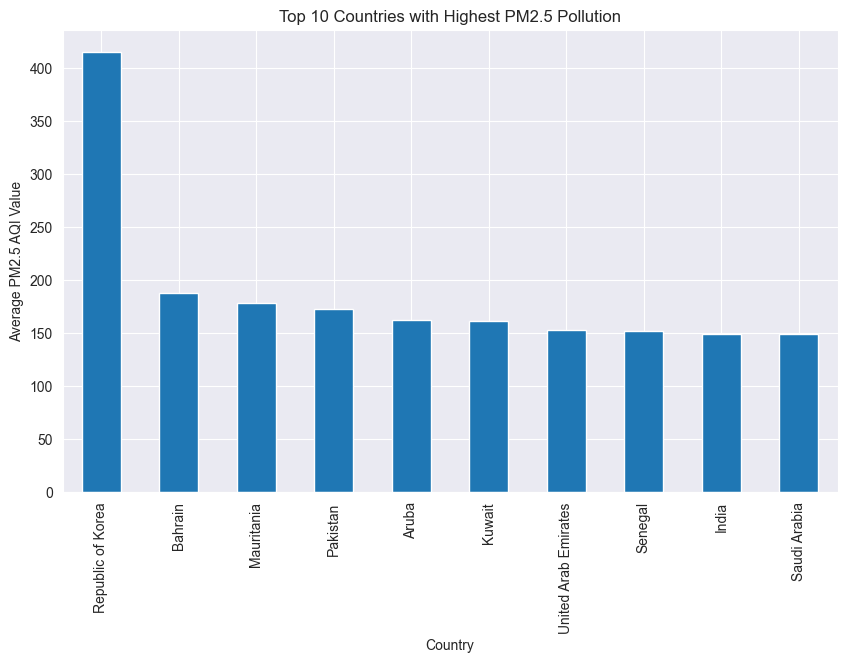

In [16]:
plt.figure(figsize=(10,6))

top_countries.plot(kind='bar')

plt.title('Top 10 Countries with Highest PM2.5 Pollution')
plt.xlabel('Country')
plt.ylabel('Average PM2.5 AQI Value')

plt.show()

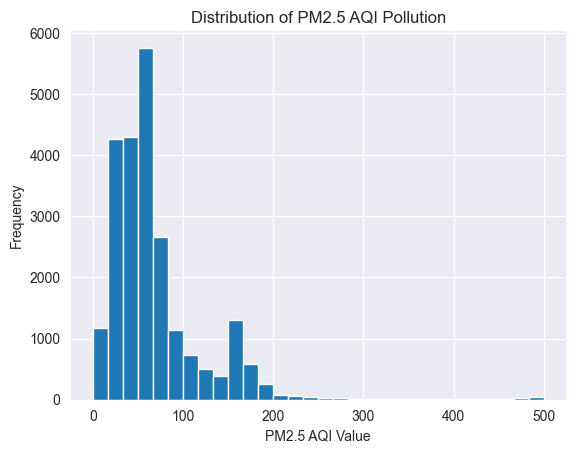

In [19]:
df['PM2.5 AQI Value'].hist(bins=30)

plt.title('Distribution of PM2.5 AQI Pollution')
plt.xlabel('PM2.5 AQI Value')
plt.ylabel('Frequency')

plt.show()

In [38]:
df.groupby(['Country','City'])['PM2.5 AQI Value'].mean().sort_values(ascending=False).head(10).round(2).reset_index()

,Country,City,PM2.5 AQI Value
0,India,Bikaner,500.0
1,India,Sisauli,500.0
2,India,Indri,500.0
3,India,Kandhla,500.0
4,United States of America,Durango,500.0
5,India,Pilkhuwa,500.0
6,India,Nilokheri,500.0
7,India,Siwani,500.0
8,India,Gunnaur,500.0
9,India,Jalalabad,500.0


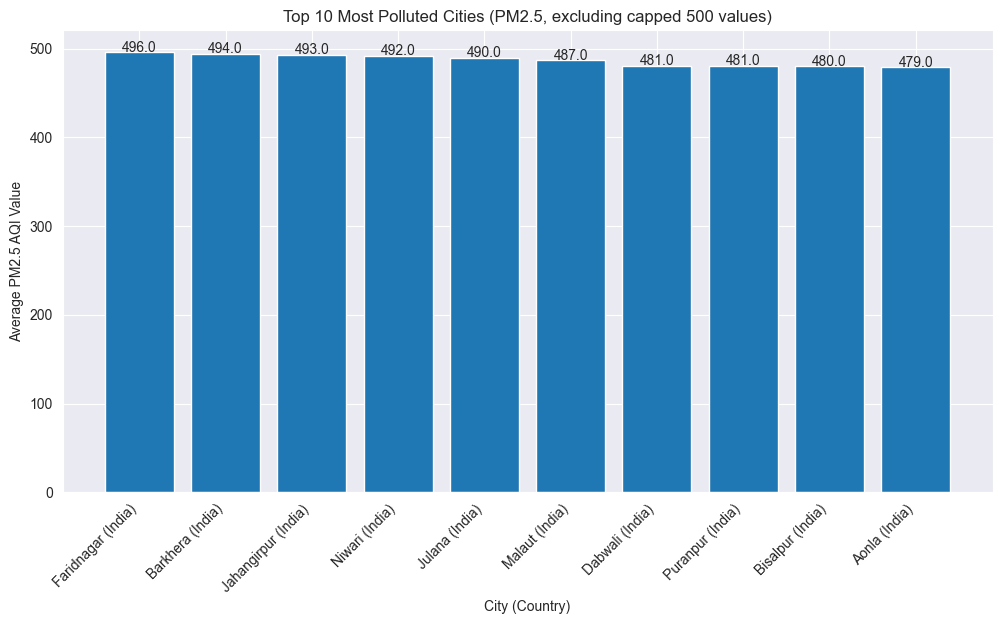

In [34]:
filtered_df = df[df['PM2.5 AQI Value'] < 500]

top_cities = (filtered_df.groupby(['Country','City'])['PM2.5 AQI Value'].mean().sort_values(ascending=False).head(10).round(2).reset_index())

top_cities['Location'] = top_cities['City'] + " (" + top_cities['Country'] + ")"

plt.figure(figsize=(12,6))

plt.bar(top_cities['Location'], top_cities['PM2.5 AQI Value'])

for i, v in enumerate(top_cities['PM2.5 AQI Value']):
    plt.text(i, v + 1, str(v), ha='center')

plt.title('Top 10 Most Polluted Cities (PM2.5, excluding capped 500 values)')
plt.xlabel('City (Country)')
plt.ylabel('Average PM2.5 AQI Value')

plt.xticks(rotation=45, ha='right')

plt.show()

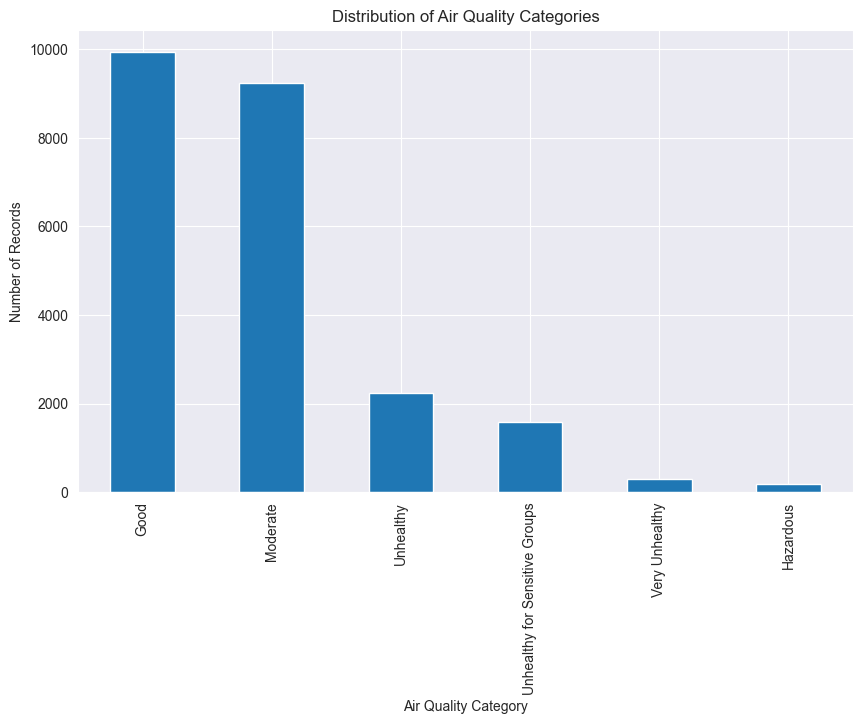

In [36]:
aqi_categories =df['AQI Category'].value_counts()

plt.figure(figsize=(10,6))
aqi_categories.plot(kind='bar')

plt.title('Distribution of Air Quality Categories')
plt.xlabel('Air Quality Category')
plt.ylabel('Number of Records')

plt.show()


Correlation analysis helps identify relationships between different pollution indicators such as CO, NO2, Ozone, and PM2.5.

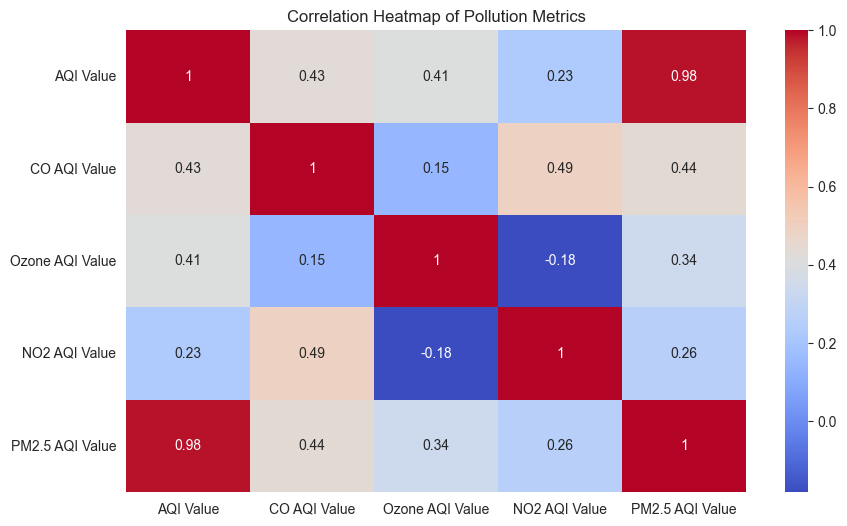

In [37]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Pollution Metrics')
plt.show()

## Key Findings

- Several countries show significantly higher PM2.5 pollution levels.
- Some cities reach the AQI maximum value of 500, indicating extremely hazardous air conditions.
- Certain cities consistently appear among the most polluted locations.
- Pollution indicators such as CO, NO2, Ozone, and PM2.5 show measurable correlations.